# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import precision_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score

In [18]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\spam_or_not_spam.csv')
df.head()

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0


In [19]:
# рассчитайте частоты для классов:
df['label'].value_counts()


label
0    2500
1     500
Name: count, dtype: int64

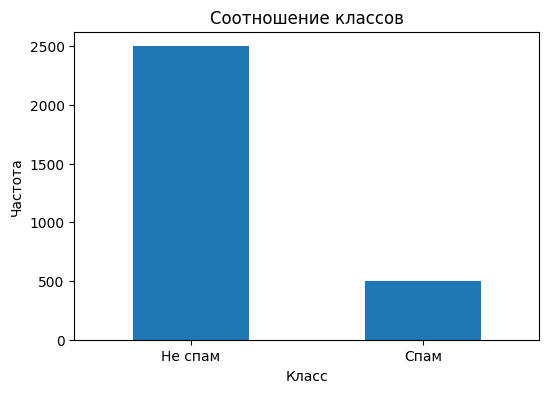

In [20]:
# визуализируйте результат:
plt.figure(figsize=(6, 4))
plt.title('Соотношение классов')
df['label'].value_counts().plot(kind='bar')
plt.xticks([0, 1], ['Не спам', 'Спам'], rotation=0)
plt.xlabel('Класс')
plt.ylabel('Частота');


## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [22]:
df['email'] = df['email'].apply(lambda x: np.nan if str(x).strip() == '' else x)
df.dropna(inplace=True)

Переводим данные в векторный вид:

In [23]:
vectorizer = CountVectorizer()
data = vectorizer.fit_transform(df["email"])

Определите, сколько теперь признаков в нашем наборе данных:

In [24]:
print(f'Количество признаков: {data.shape[0]}')

Количество признаков: 2997


## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [25]:
y = df['label']
X = data.toarray()

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [27]:
print(f'Среднее значение целевой переменной на тестовой выборке: {np.round(np.mean(y_test), 3)}')

Среднее значение целевой переменной на тестовой выборке: 0.165


## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

In [28]:
# MultinomialNB
mulNB = MultinomialNB(alpha=0.01)
mulNB.fit(X_train, y_train)
y_pred_mulNB = mulNB.predict(X_test)
print(f'Precision MultinomialNB: {np.round(precision_score(y_test, y_pred_mulNB), 3)}')
print(f'Accuracy MultinomialNB: {np.round(accuracy_score(y_test, y_pred_mulNB), 3)}')
print()

# ComplementNB
comNB = ComplementNB(alpha=0.01)
comNB.fit(X_train, y_train)
y_pred_comNB = comNB.predict(X_test)
print(f'Precision ComplementNB: {np.round(precision_score(y_test, y_pred_comNB), 3)}')
print(f'Accuracy ComplementNB: {np.round(accuracy_score(y_test, y_pred_comNB), 3)}')



Precision MultinomialNB: 1.0
Accuracy MultinomialNB: 0.987

Precision ComplementNB: 1.0
Accuracy ComplementNB: 0.988


Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [29]:
model_name = 'Отчет по метрикам для MultinomialNB:'
print('='*53)
print(f'{model_name.upper():^60}')
print('='*53)
print(classification_report(y_test, y_pred_mulNB))

print()

model_name1 = 'Отчет по метрикам для ComplementNB:'
print('='*53)
print(f'{model_name1.upper():^60}')
print('='*53)
print(classification_report(y_test, y_pred_comNB))

            ОТЧЕТ ПО МЕТРИКАМ ДЛЯ MULTINOMIALNB:            
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       626
           1       1.00      0.92      0.96       124

    accuracy                           0.99       750
   macro avg       0.99      0.96      0.98       750
weighted avg       0.99      0.99      0.99       750


            ОТЧЕТ ПО МЕТРИКАМ ДЛЯ COMPLEMENTNB:             
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       626
           1       1.00      0.93      0.96       124

    accuracy                           0.99       750
   macro avg       0.99      0.96      0.98       750
weighted avg       0.99      0.99      0.99       750



По полученным метрикам можно сделать вывод, что использованные алгоритмы классификации очень хорошо справляются с поставленной задачей и имеют практически 100% точность.

Нарисуйте ROC-кривую:

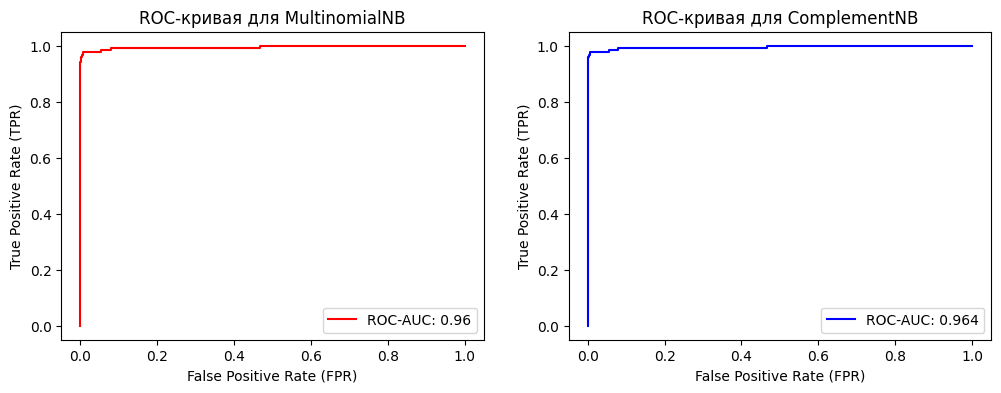

In [30]:
# Считаем метрики
y_pred_proba_mulNB = mulNB.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_mulNB) 
ROC_mulNB = roc_auc_score(y_test, y_pred_mulNB)

y_pred_proba_comNB = comNB.predict_proba(X_test)[:, 1]
fpr1, tpr1, thresholds1 = roc_curve(y_test, y_pred_proba_comNB) 
ROC_comNB = roc_auc_score(y_test, y_pred_comNB)

# Строим график
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, color='red', label=f'ROC-AUC: {np.round(ROC_mulNB, 3)}')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC-кривая для MultinomialNB')
axes[0].legend(loc="lower right")

axes[1].plot(fpr1, tpr1, color='blue', label=f'ROC-AUC: {np.round(ROC_comNB, 3)}')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('ROC-кривая для ComplementNB')
axes[1].legend(loc="lower right");

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [31]:
metrics_accuracy = []
metrics_recall = []
metrics_precision = []
metrics_f1 = []
alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2]
for alpha in alphas:
    mulNB = MultinomialNB(alpha=alpha)
    # Считаем 4 основные метрики
    score_accuracy = np.mean(cross_val_score(mulNB, X_train, y_train, cv=3, scoring='accuracy'))
    score_recall = np.mean(cross_val_score(mulNB, X_train, y_train, cv=3, scoring='recall'))
    score_precision = np.mean(cross_val_score(mulNB, X_train, y_train, cv=3, scoring='precision'))
    score_f1 = np.mean(cross_val_score(mulNB, X_train, y_train, cv=3, scoring='f1'))
    # Добавляем каждую в список
    metrics_accuracy.append(score_accuracy)
    metrics_recall.append(score_recall)
    metrics_precision.append(score_precision)
    metrics_f1.append(score_f1)

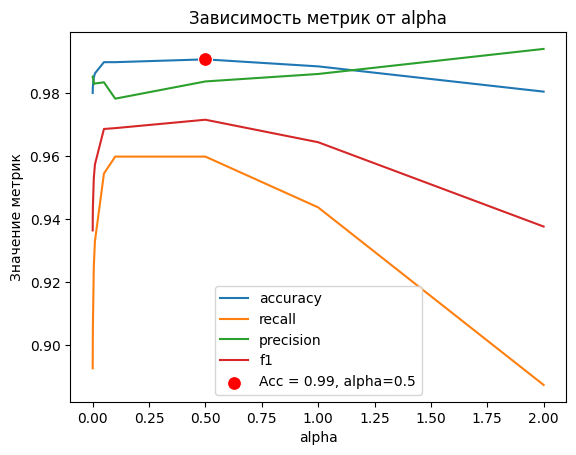

In [32]:
# Поиск наилучшего значения alpha
max_index = np.argmax(metrics_accuracy)
element_accuracy = metrics_accuracy[max_index]
element_alpha = alphas[max_index]

# График
sns.lineplot(y=metrics_accuracy, x=alphas, label='accuracy')
sns.lineplot(y=metrics_recall, x=alphas, label='recall')
sns.lineplot(y=metrics_precision, x=alphas, label='precision')
sns.lineplot(y=metrics_f1, x=alphas, label='f1')
sns.scatterplot(x=[element_alpha], y=[element_accuracy], s=100, color='red', 
                label=f'Acc = {np.round(element_accuracy, 2)}, alpha={element_alpha}', zorder=10)
plt.title('Зависимость метрик от alpha')
plt.xlabel('alpha')
plt.ylabel('Значение метрик');

Максимальное значение accuracy=0.99 наблюдается при alpha=0.5

При увеличение alpha все метрики кроме precision начинают резко падать